In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
data = {
    "news": [
        "The government announced a new public transportation project for the city.",
        "Scientists published a study about improving renewable energy efficiency.",
        "The central bank released its latest economic policy statement.",
        "The university announced the schedule for the upcoming academic semester.",
        "The weather department issued an official warning about heavy rainfall.",
        "The company reported its quarterly financial results to investors.",
        "Researchers developed a new method for improving battery performance.",
        "The health department launched a public awareness campaign.",
        "The election commission released the official voting schedule.",
        "The space agency announced the successful launch of a research satellite.",

        "Scientists discovered that eating one special fruit gives humans superpowers.",
        "A secret machine can make unlimited money from ordinary paper.",
        "The government will give every citizen a free luxury car tomorrow.",
        "Doctors confirmed that sleeping for one minute completely replaces exercise.",
        "A mysterious device can make anyone instantly become a millionaire.",
        "Experts claim that drinking only one glass of water can cure every disease.",
        "A hidden city was reportedly discovered underneath the ocean overnight.",
        "Scientists say humans will never need food again after taking a magic pill.",
        "A celebrity reportedly bought the entire country using cryptocurrency.",
        "A new phone reportedly works forever without charging."
    ],

    "label": [
        "Real", "Real", "Real", "Real", "Real",
        "Real", "Real", "Real", "Real", "Real",

        "Fake", "Fake", "Fake", "Fake", "Fake",
        "Fake", "Fake", "Fake", "Fake", "Fake"
    ]
}

df = pd.DataFrame(data)

print("News dataset created successfully!")
print("Number of news articles:", len(df))

df.head()

News dataset created successfully!
Number of news articles: 20


,news,label
0,The government announced a new public transpor...,Real
1,Scientists published a study about improving r...,Real
2,The central bank released its latest economic ...,Real
3,The university announced the schedule for the ...,Real
4,The weather department issued an official warn...,Real


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNews Label Distribution:")
print(df["label"].value_counts())

print("\nDataset Preview:")
print(df.head())

Dataset Shape:
(20, 2)

Column Names:
['news', 'label']

Missing Values:
news     0
label    0
dtype: int64

News Label Distribution:
label
Real    10
Fake    10
Name: count, dtype: int64

Dataset Preview:
                                                news label
0  The government announced a new public transpor...  Real
1  Scientists published a study about improving r...  Real
2  The central bank released its latest economic ...  Real
3  The university announced the schedule for the ...  Real
4  The weather department issued an official warn...  Real


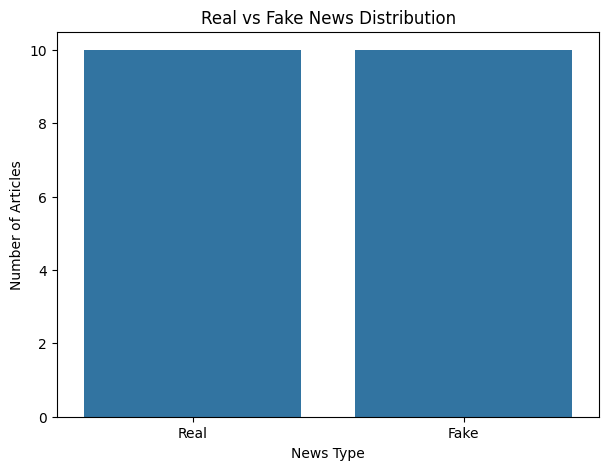

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Real vs Fake News Distribution")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.show()

In [6]:
X = df["news"]
y = df["label"]

print("Input News:")
print(X.head())

print("\nTarget Labels:")
print(y.head())

Input News:
0    The government announced a new public transpor...
1    Scientists published a study about improving r...
2    The central bank released its latest economic ...
3    The university announced the schedule for the ...
4    The weather department issued an official warn...
Name: news, dtype: object

Target Labels:
0    Real
1    Real
2    Real
3    Real
4    Real
Name: label, dtype: object


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training news articles:", len(X_train))
print("Testing news articles:", len(X_test))

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training news articles: 15
Testing news articles: 5

Training labels:
label
Real    8
Fake    7
Name: count, dtype: int64

Testing labels:
label
Fake    3
Real    2
Name: count, dtype: int64


In [8]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

# Learn vocabulary from training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform testing data using the same vocabulary
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF conversion completed!")

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training TF-IDF shape: (15, 174)
Testing TF-IDF shape: (5, 174)


In [9]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train_tfidf, y_train)

print("Fake news detection model trained successfully!")

Fake news detection model trained successfully!


In [10]:
# Predict the labels for test data
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", f"{accuracy:.2%}")

Model Accuracy: 40.00%


In [11]:
report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        Fake       0.00      0.00      0.00         3
        Real       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



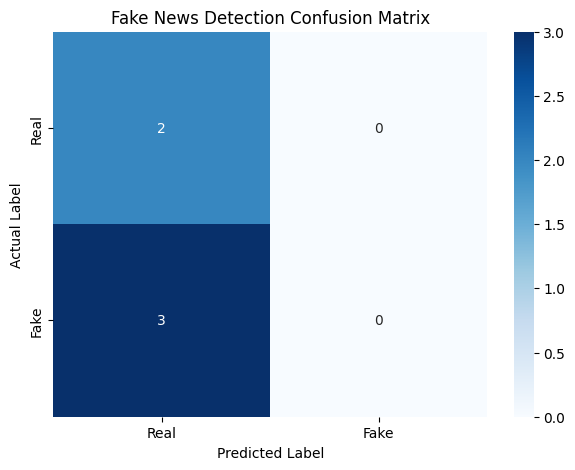

In [12]:
labels = ["Real", "Fake"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Fake News Detection Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [13]:
def predict_news(news_text):
    # Convert new news into TF-IDF features
    news_tfidf = vectorizer.transform([news_text])

    # Predict the label
    prediction = model.predict(news_tfidf)[0]

    # Get confidence score
    confidence = model.predict_proba(news_tfidf).max()

    return prediction, confidence


# Test the function
news = "The government announced a new public transportation project."

prediction, confidence = predict_news(news)

print("News:", news)
print("Predicted Label:", prediction)
print("Confidence:", f"{confidence:.2%}")

News: The government announced a new public transportation project.
Predicted Label: Real
Confidence: 61.90%


In [14]:
test_news = [
    "Scientists published a new study about renewable energy technology.",
    "A magical device can make every person a millionaire overnight.",
    "The university announced the schedule for the next academic semester."
]

for news in test_news:
    prediction, confidence = predict_news(news)

    print("News:", news)
    print("Predicted Label:", prediction)
    print("Confidence:", f"{confidence:.2%}")
    print("-" * 70)

News: Scientists published a new study about renewable energy technology.
Predicted Label: Real
Confidence: 59.45%
----------------------------------------------------------------------
News: A magical device can make every person a millionaire overnight.
Predicted Label: Fake
Confidence: 50.96%
----------------------------------------------------------------------
News: The university announced the schedule for the next academic semester.
Predicted Label: Real
Confidence: 62.66%
----------------------------------------------------------------------


In [15]:
print("==========================================")
print("        AI FAKE NEWS DETECTOR")
print("==========================================")
print("Type 'exit' to stop the detector.\n")

while True:
    user_news = input("Enter news article: ")

    if user_news.lower() == "exit":
        print("\nFake news detection stopped.")
        break

    if user_news.strip() == "":
        print("Please enter a valid news article.\n")
        continue

    prediction, confidence = predict_news(user_news)

    print("\nPredicted Label:", prediction)
    print("Confidence:", f"{confidence:.2%}")
    print("-" * 60)

        AI FAKE NEWS DETECTOR
Type 'exit' to stop the detector.

Enter news article: The university announced a new academic program for students.

Predicted Label: Real
Confidence: 60.75%
------------------------------------------------------------
Enter news article: exit

Fake news detection stopped.


In [16]:
import joblib

# Save the trained model
joblib.dump(model, "fake_news_detection_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "fake_news_tfidf_vectorizer.pkl")

# Save the dataset
df.to_csv("fake_news_dataset.csv", index=False)

print("Project files saved successfully!")

print("\nFiles created:")
print("1. fake_news_detection_model.pkl")
print("2. fake_news_tfidf_vectorizer.pkl")
print("3. fake_news_dataset.csv")

Project files saved successfully!

Files created:
1. fake_news_detection_model.pkl
2. fake_news_tfidf_vectorizer.pkl
3. fake_news_dataset.csv


In [17]:
import os

print("==========================================")
print("          PROJECT FILE CHECK")
print("==========================================")

files = [
    "fake_news_detection_model.pkl",
    "fake_news_tfidf_vectorizer.pkl",
    "fake_news_dataset.csv"
]

for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✓ {file}  ({size} bytes)")
    else:
        print(f"✗ {file}  (Not found)")

          PROJECT FILE CHECK
✓ fake_news_detection_model.pkl  (2399 bytes)
✓ fake_news_tfidf_vectorizer.pkl  (5069 bytes)
✓ fake_news_dataset.csv  (1507 bytes)


In [18]:
print("==========================================")
print("        AI FAKE NEWS DETECTION")
print("==========================================")

print("\nProject Summary:")
print("• Domain: Artificial Intelligence / NLP")
print("• Platform: Google Colab")
print("• Language: Python")
print("• Dataset: News Articles")
print("• Classes: Real and Fake")
print("• Text Processing: TF-IDF")
print("• Machine Learning Algorithm: Logistic Regression")
print("• Evaluation: Accuracy, Classification Report, Confusion Matrix")
print("• Feature: Interactive News Prediction")

print("\nProject completed successfully!")

        AI FAKE NEWS DETECTION

Project Summary:
• Domain: Artificial Intelligence / NLP
• Platform: Google Colab
• Language: Python
• Dataset: News Articles
• Classes: Real and Fake
• Text Processing: TF-IDF
• Machine Learning Algorithm: Logistic Regression
• Evaluation: Accuracy, Classification Report, Confusion Matrix
• Feature: Interactive News Prediction

Project completed successfully!
